# Caso2: Factores que Impactan el Desempeño en Matemáticas
  
**Objetivo:** Identificar los factores que más influyen en el rendimiento académico de estudiantes universitarios.

---

## Contenido
1. Carga y exploración inicial del dataset
2. Diccionario de datos
3. Visualizaciones y hallazgos
4. Transformaciones necesarias

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Estilo de gráficos
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

In [2]:
URL = (
    "https://raw.githubusercontent.com/daramireh/"
    "simonBolivarCienciaDatos/refs/heads/main/"
    "Student_Performance.csv"
)

df = pd.read_csv(URL)

print(f"Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"Columnas: {list(df.columns)}")
print()
df.head(10)

Dimensiones del dataset: 10000 filas x 6 columnas
Columnas: ['Hours Studied', 'Previous Scores', 'Extracurricular Activities', 'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index']



,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
5,3,78,No,9,6,61.0
6,7,73,Yes,5,6,63.0
7,8,45,Yes,4,6,42.0
8,5,77,No,8,2,61.0
9,4,89,No,4,0,69.0


### Identificación de cada variable

In [3]:
# Diccionario de datos 
diccionario = pd.DataFrame({
    'variable': df.columns,
    'tipo_python': df.dtypes.values,
    'nulos': df.isnull().sum().values,
    'pct_nulos': (df.isnull().mean() * 100).round(2).values,
    'valores_unicos': df.nunique().values,
    'ejemplo_valor': [df[c].dropna().iloc[0] for c in df.columns]
})

diccionario = diccionario.reset_index(drop=True)

pd.set_option('display.max_colwidth', 60)
diccionario

,variable,tipo_python,nulos,pct_nulos,valores_unicos,ejemplo_valor
0,Hours Studied,int64,0,0.0,9,7
1,Previous Scores,int64,0,0.0,60,99
2,Extracurricular Activities,object,0,0.0,2,Yes
3,Sleep Hours,int64,0,0.0,6,9
4,Sample Question Papers Practiced,int64,0,0.0,10,1
5,Performance Index,float64,0,0.0,91,91.0


In [4]:
print(
    "Duplicados:",
    df.duplicated().sum()
)

Duplicados: 127


Para identificar qué es cada variables:

**Hours Studied:** Horas de estudio promedio por semana (variable numérica discreta)

**Previous Scores:** Puntaje promedio en evaluaciones anteriores (0-100) (variable numérica continua)

**Extracurricular Activities:** Asistencia a actividades extracurriculares (Yes/No) (variable categórica nominal)

**Sleep Hours:** Horas de sueño promedio por noche (variable numérica discreta)

**Sample Question Papers Practiced:** Cantidad de ejercicios prácticos resueltos (variable numérica discreta)

**Performance Index:** Índice de rendimiento final (variable objetivo, 0-100) (variable numérica continua)

Vemos que en el dataset cuenta con 6 variables y no presenta valores nulos. La variable objetivo es índice de rendimiento final, un índice continuo que representa el rendimiento final del estudiante.

La única variable categórica es las Actividades Extracurriculares (siendo de categprias Si/No), que requere codificación binaria. Las variables numéricas discretas (horas de estudio, sueño, ejercicios) tienen rangos acotados, lo que facilita la detección de outliers Y los Puntaje de examenes anteriores captura el historial académico previo, que pudiera ser uno de los predictores del rendimiento.

## 3. Visualizaciones

### Distribución de variables numéricas

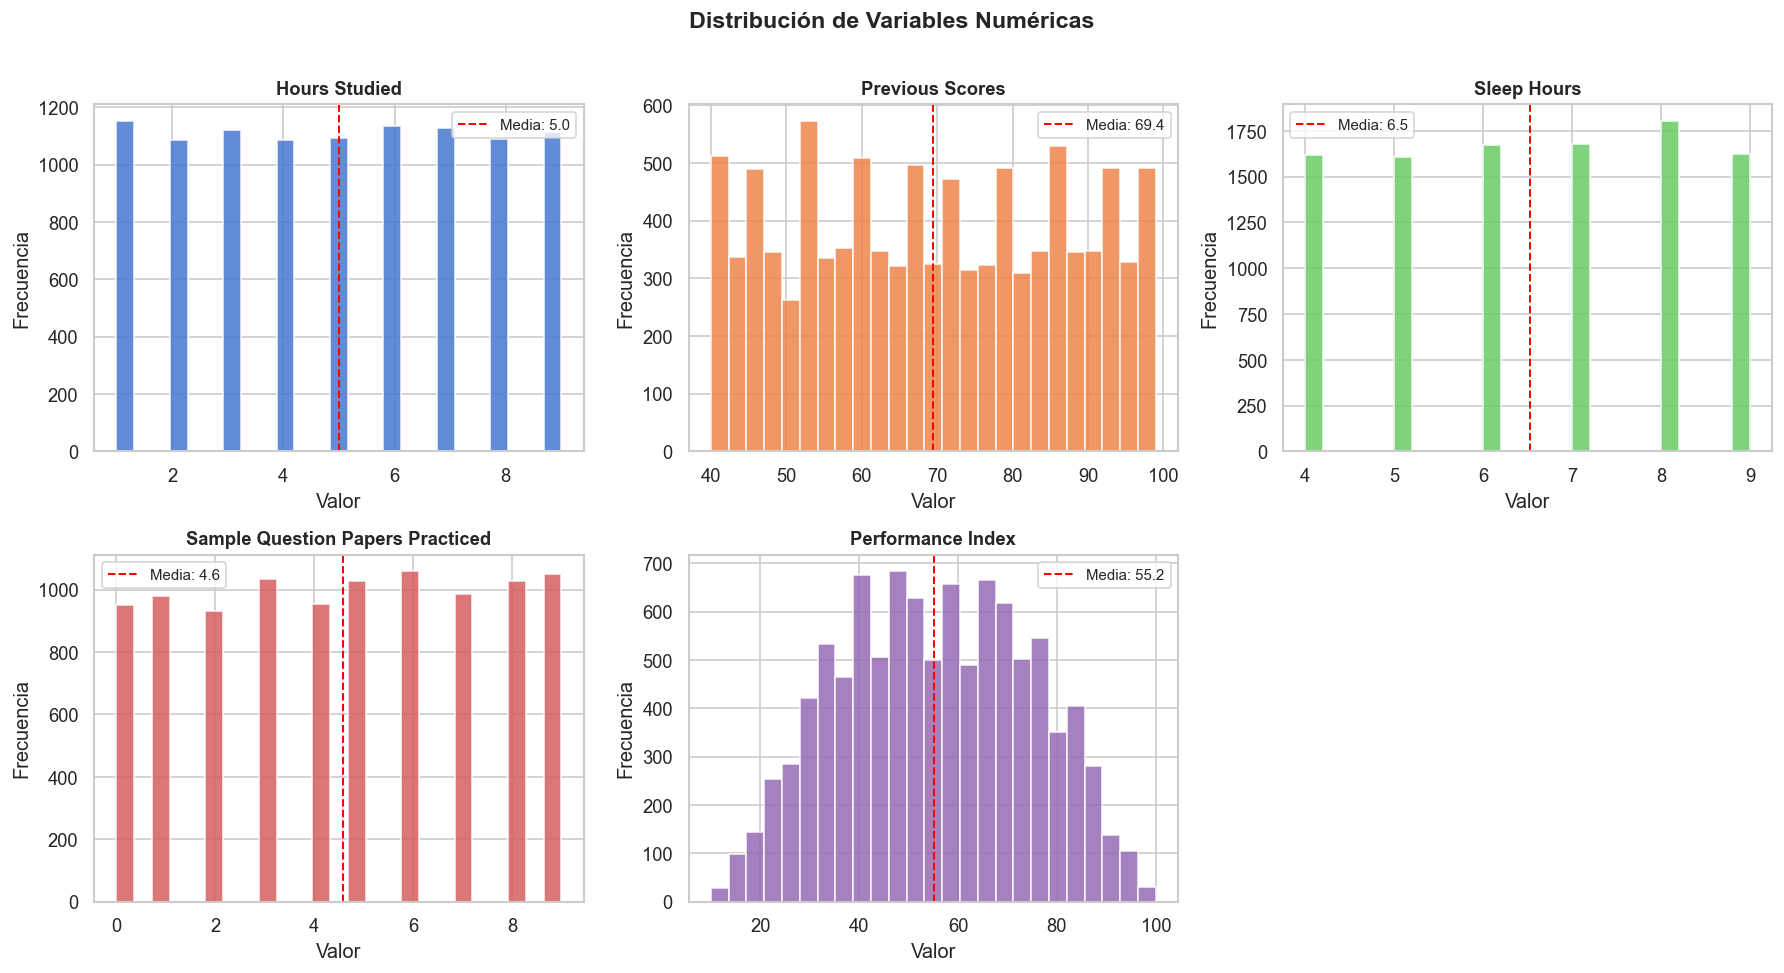

In [5]:
num_cols = df.select_dtypes(include='number').columns.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

colors = ['#4878D0', '#EE854A', '#6ACC65', '#D65F5F', '#956CB4', '#8C613C']

for i, col in enumerate(num_cols):
    axes[i].hist(
        df[col],
        bins=25,
        color=colors[i],
        edgecolor='white',
        alpha=0.85
    )

    axes[i].set_title(col, fontweight='bold', fontsize=11)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')

    mean_val = df[col].mean()
    axes[i].axvline(
        mean_val,
        color='red',
        linestyle='--',
        linewidth=1.2,
        label=f'Media: {mean_val:.1f}'
    )
    axes[i].legend(fontsize=9)

# Eliminar subplots vacíos
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    'Distribución de Variables Numéricas',
    fontsize=14,
    fontweight='bold',
    y=1.01
)

plt.tight_layout()
plt.savefig('../data/distribucion_variables.png',
            dpi=150,
            bbox_inches='tight')
plt.show()

Las distribuciones de `Hora de estudio`, `Horas de sueño` y `Cantidad de ejercicios resueltos` son aprox. uniformes. El `Rendimiento final` muestra una distribución relativamente normal con una leve asimetría. Y los `Puntajes de evaluaciones anteriores` también presenta distribución uniforme en el rango 40–99.

### Variable categórica = Actividades extracurriculares

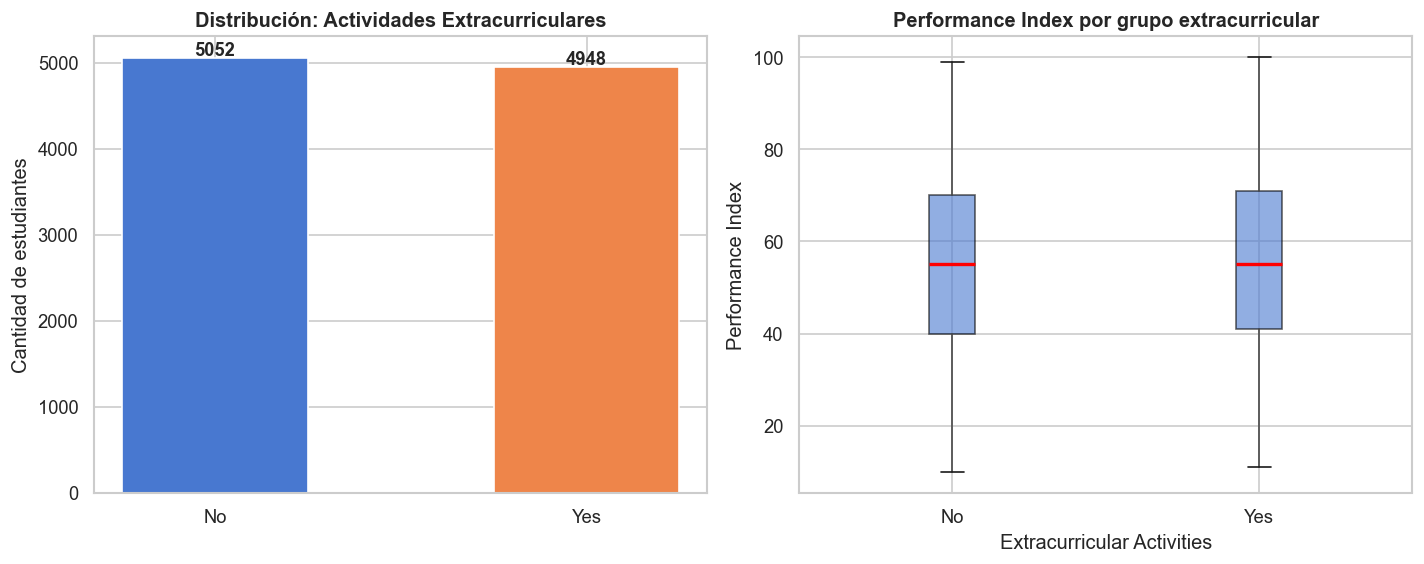

,count,mean,std,min,25%,50%,75%,max
Extracurricular Activities,,,,,,,,
No,5052.0,54.76,19.15,10.0,40.0,55.0,70.0,99.0
Yes,4948.0,55.70,19.26,11.0,41.0,55.0,71.0,100.0


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Conteo
conteo = df['Extracurricular Activities'].value_counts()
axes[0].bar(conteo.index, conteo.values, color=['#4878D0', '#EE854A'], edgecolor='white', width=0.5)
axes[0].set_title('Distribución: Actividades Extracurriculares', fontweight='bold')
axes[0].set_ylabel('Cantidad de estudiantes')
for i, v in enumerate(conteo.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# Boxplot Performance Index por grupo
df.boxplot(column='Performance Index', by='Extracurricular Activities',
           ax=axes[1], patch_artist=True,
           boxprops=dict(facecolor='#4878D0', alpha=0.6),
           medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Performance Index por grupo extracurricular', fontweight='bold')
axes[1].set_xlabel('Extracurricular Activities')
axes[1].set_ylabel('Performance Index')
plt.suptitle('')

plt.tight_layout()
plt.savefig('../data/extracurricular_analisis.png', dpi=150, bbox_inches='tight')
plt.show()

# Estadísticas por grupo
df.groupby('Extracurricular Activities')['Performance Index'].describe().round(2)

La distribución entre estudiantes con y sin actividades extracurriculares es casi equivalente (50/50). El boxplot muestra medianas similares entre ambos grupos, aunque se observan diferencias en la dispersión.

### Mapa de correlaciones

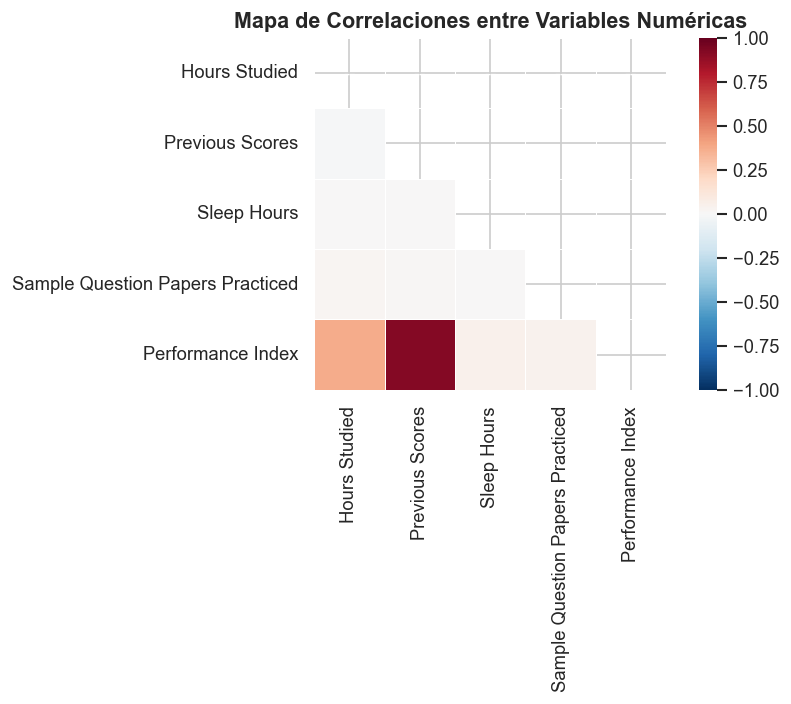

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))

corr_matrix = df[num_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    mask=mask,
    ax=ax,
    linewidths=0.5,
    square=True,
    vmin=-1, vmax=1
)

ax.set_title('Mapa de Correlaciones entre Variables Numéricas', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../data/correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()

Se observa una correlación positiva moderada-alta entre las `Horas de estudio` y el `Rendimiento final`, confirmando que el tiempo de estudio es un factor determinante. El `Puntaje de las evaluaciones anterioes` también muestra correlación positiva con el rendimiento final. Pero las `Horas de estudio` y la `Cantidad de ejercicios resueltos` presentan correlaciones más débiles. No se detecta multicolinealidad problemática entre las variables independientes.

### Relación tiempo de estudio vs rendimiento

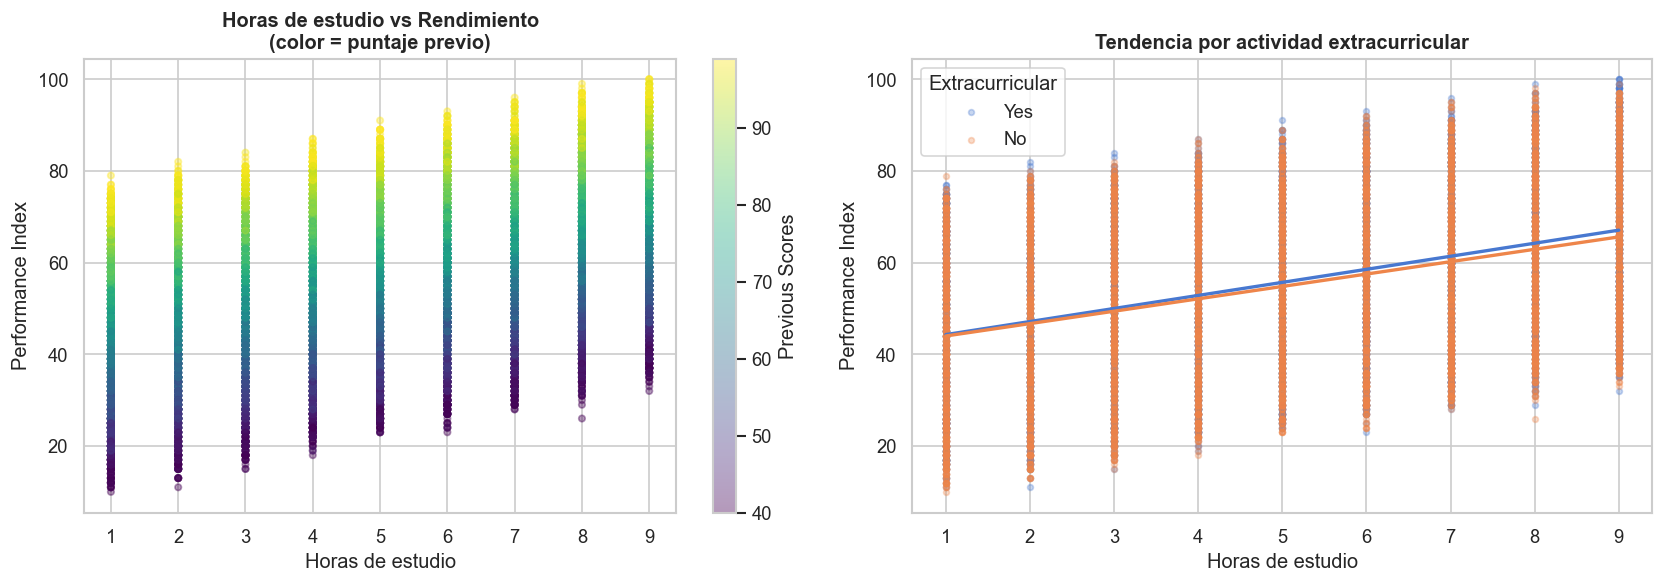

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: Hours Studied vs Performance Index
scatter = axes[0].scatter(
    df['Hours Studied'], df['Performance Index'],
    c=df['Previous Scores'], cmap='viridis', alpha=0.4, s=15
)
plt.colorbar(scatter, ax=axes[0], label='Previous Scores')
axes[0].set_xlabel('Horas de estudio')
axes[0].set_ylabel('Performance Index')
axes[0].set_title('Horas de estudio vs Rendimiento\n(color = puntaje previo)', fontweight='bold')

# Línea de tendencia por grupo extracurricular
for label, color in [('Yes', '#4878D0'), ('No', '#EE854A')]:
    subset = df[df['Extracurricular Activities'] == label]
    axes[1].scatter(subset['Hours Studied'], subset['Performance Index'],
                    alpha=0.3, s=12, color=color, label=label)
    z = np.polyfit(subset['Hours Studied'], subset['Performance Index'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(subset['Hours Studied'].min(), subset['Hours Studied'].max(), 100)
    axes[1].plot(x_line, p(x_line), color=color, linewidth=2)

axes[1].set_xlabel('Horas de estudio')
axes[1].set_ylabel('Performance Index')
axes[1].set_title('Tendencia por actividad extracurricular', fontweight='bold')
axes[1].legend(title='Extracurricular')

plt.tight_layout()
plt.savefig('../data/estudio_vs_rendimiento.png', dpi=150, bbox_inches='tight')
plt.show()

Existe una tendencia positiva clara entre las horas de estudio y el Rendimiento final. Los estudiantes que estudian más horas tienden a obtener mejores resultados, independientemente de si participan o no en actividades extracurriculares. Las líneas de tendencia para ambos grupos son paralelas, dando el efecto de que las horas de estudio son casi iguales.

### Detección de outliers con boxplots

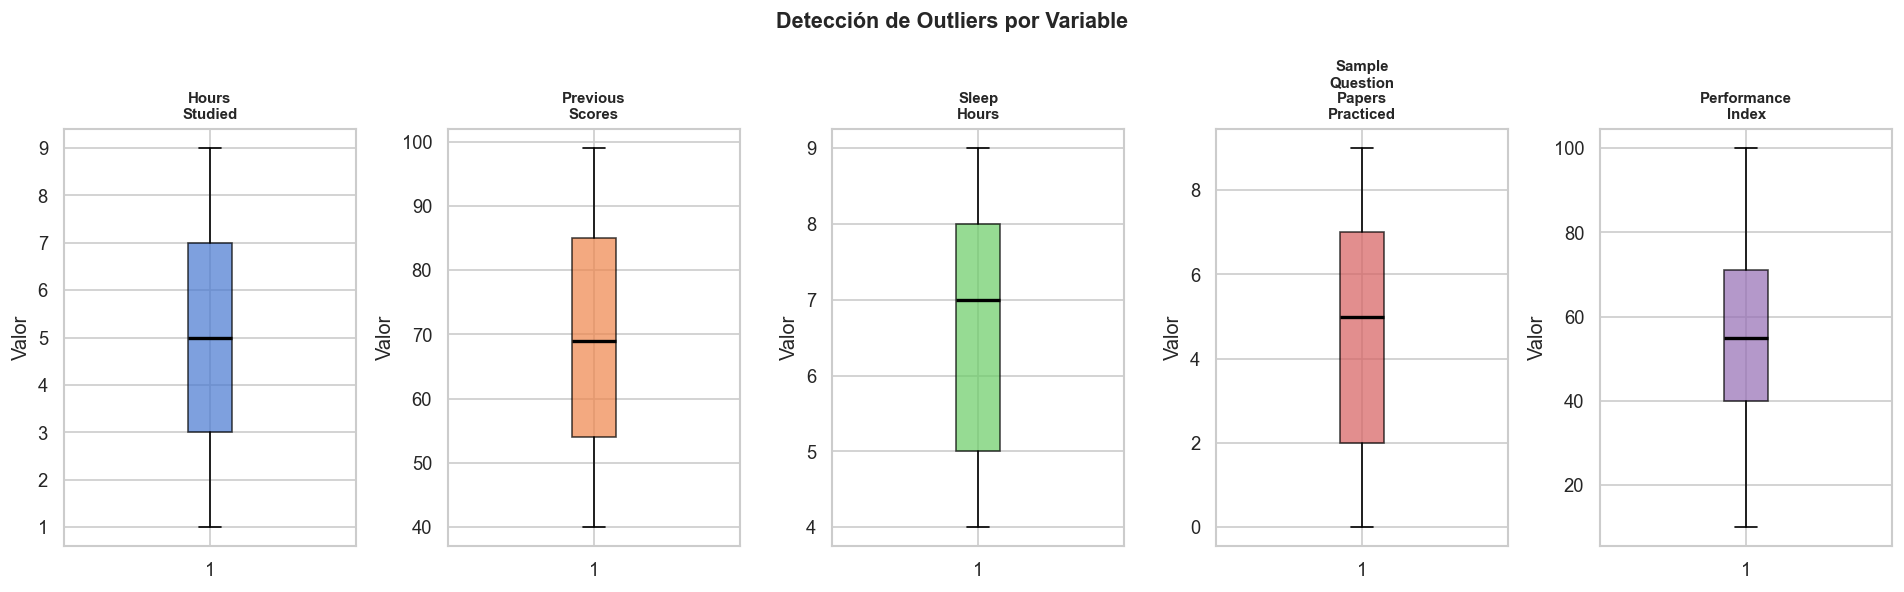

Outliers por variable (método IQR):
  Hours Studied: 0 outliers
  Previous Scores: 0 outliers
  Sleep Hours: 0 outliers
  Sample Question Papers Practiced: 0 outliers
  Performance Index: 0 outliers


In [9]:
fig, axes = plt.subplots(1, len(num_cols), figsize=(16, 5))

for i, col in enumerate(num_cols):
    bp = axes[i].boxplot(df[col], patch_artist=True,
                         boxprops=dict(facecolor=colors[i], alpha=0.7),
                         medianprops=dict(color='black', linewidth=2),
                         flierprops=dict(marker='o', markerfacecolor='red', markersize=4, alpha=0.5))
    axes[i].set_title(col.replace(' ', '\n'), fontsize=9, fontweight='bold')
    axes[i].set_ylabel('Valor')

plt.suptitle('Detección de Outliers por Variable', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/boxplots_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

# Contar outliers por variable
print('Outliers por variable (método IQR):')
for col in num_cols:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    print(f"  {col}: {n_out} outliers")

Los boxplots muestran una distribución bastante similar en la mayoría de las variables. La cantidad de outliers es mínima, lo que confirma que el dataset no requiere tanta elimiación en los registros. 

## Transformaciones de Datos

Las transformaciones identificadas fueron:
1. **Codificación binaria** de `Actividades extracurriculares` (Yes = Sí → 1, No → 0)
2. **Creación de variable objetivo** `Rendimientos bajos` para el modelo de clasificación
3. **Renombrado de columnas** para facilitar el manejo en código

In [10]:
# Codificación binaria
df['extracurricular'] = (df['Extracurricular Activities'] == 'Yes').astype(int)
print('Distribución de extracurricular codificado:')
print(df['extracurricular'].value_counts())

Distribución de extracurricular codificado:
extracurricular
0    5052
1    4948
Name: count, dtype: int64


In [11]:
# Variable de bajo rendimiento
# Criterio: estudiantes en el cuartil inferior (Q1) del Performance Index
Q1 = df['Performance Index'].quantile(0.25)
Q3 = df['Performance Index'].quantile(0.75)
IQR = Q3 - Q1
threshold = Q1  

df['rendimiento_bajo'] = (df['Performance Index'] < threshold).astype(int)

print(f'Umbral de bajo rendimiento (Q1): {threshold:.2f}')
print(f'Distribución de low_performance:')
print(df['rendimiento_bajo'].value_counts())
print(f'\n% Estudiantes con bajo rendimiento: {df["rendimiento_bajo"].mean()*100:.1f}%')

Umbral de bajo rendimiento (Q1): 40.00
Distribución de low_performance:
rendimiento_bajo
0    7618
1    2382
Name: count, dtype: int64

% Estudiantes con bajo rendimiento: 23.8%


In [12]:
# Renombrado de columnas
df = df.rename(columns={
    'Hours Studied': 'horas_de_estudio',
    'Previous Scores': 'resultados_anteriores',
    'Extracurricular Activities': 'extracurricular_2',
    'Sleep Hours': 'horas_sueño',
    'Sample Question Papers Practiced': 'num_ejercicios_resueltos',
    'Performance Index': 'indice_rendimiento'
})

print('Columnas finales del dataset transformado:')
print(df.columns.tolist())
df.head(5)

Columnas finales del dataset transformado:
['horas_de_estudio', 'resultados_anteriores', 'extracurricular_2', 'horas_sueño', 'num_ejercicios_resueltos', 'indice_rendimiento', 'extracurricular', 'rendimiento_bajo']


,horas_de_estudio,resultados_anteriores,extracurricular_2,horas_sueño,num_ejercicios_resueltos,indice_rendimiento,extracurricular,rendimiento_bajo
0,7,99,Yes,9,1,91.0,1,0
1,4,82,No,4,2,65.0,0,0
2,8,51,Yes,7,2,45.0,1,0
3,5,52,Yes,5,2,36.0,1,1
4,7,75,No,8,5,66.0,0,0


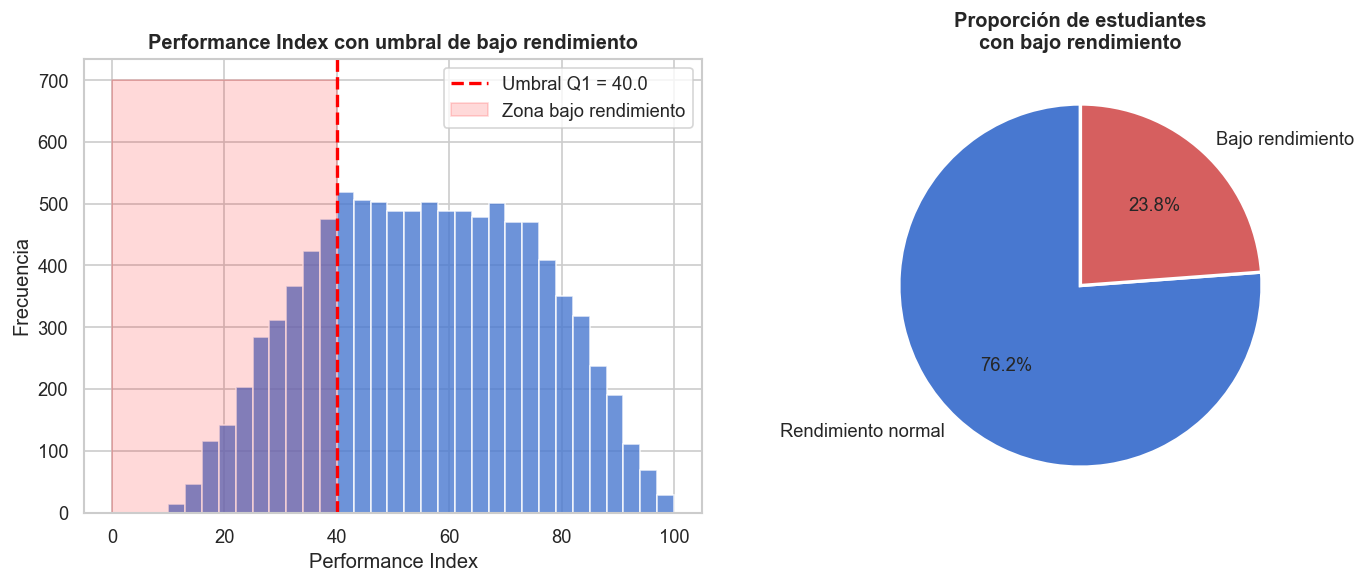

In [13]:
# Distribución de bajo rendimiento
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histograma con umbral marcado
axes[0].hist(df['indice_rendimiento'], bins=30, color='#4878D0', edgecolor='white', alpha=0.8)
axes[0].axvline(threshold, color='red', linestyle='--', linewidth=2, label=f'Umbral Q1 = {threshold:.1f}')
axes[0].fill_betweenx([0, 700], 0, threshold, alpha=0.15, color='red', label='Zona bajo rendimiento')
axes[0].set_title('Performance Index con umbral de bajo rendimiento', fontweight='bold')
axes[0].set_xlabel('Performance Index')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# Pie chart
conteo_lp = df['rendimiento_bajo'].value_counts()
axes[1].pie(
    conteo_lp.values,
    labels=['Rendimiento normal', 'Bajo rendimiento'],
    colors=['#4878D0', '#D65F5F'],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
axes[1].set_title('Proporción de estudiantes\ncon bajo rendimiento', fontweight='bold')

plt.tight_layout()
plt.savefig('../data/bajo_rendimiento_distribucion.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# Guardar dataset transformado
df.to_csv('../data/student_performance_clean.csv', index=False)
print('Dataset transformado guardado en data/student_performance_clean.csv')
print(f'Shape final: {df.shape}')
print()

Dataset transformado guardado en data/student_performance_clean.csv
Shape final: (10000, 8)



| Aspecto | Hallazgo |
|---|---|
| Calidad de datos | Dataset limpio: 0 nulos, duplicados evidentes |
| Variable más correlacionada | `Horas de estudio` con `Índice de rendimiento` |
| Variable objetivo regresión | `Índice de rendimiento` (continua, rango 10–100) |
| Variable objetivo clasificación | `Bajo rendimiento` (binaria, umbral = Q1) |
| Transformaciones aplicadas | Codificación binaria + nueva variable + renombrado |
| Outliers | Mínimos, no requieren tratamiento agresivo |

# Análisis Exploratorio de Datos

## Estadística Descriptiva

In [15]:
desc = df.select_dtypes(include='number').describe().T.round(2)
desc['CV (%)'] = (desc['std'] / desc['mean'] * 100).round(1)  # coeficiente de variación
desc['rango'] = desc['max'] - desc['min']
print('Estadística Descriptiva')
desc

Estadística Descriptiva


,count,mean,std,min,25%,50%,75%,max,CV (%),rango
horas_de_estudio,10000.0,4.99,2.59,1.0,3.0,5.0,7.0,9.0,51.9,8.0
resultados_anteriores,10000.0,69.45,17.34,40.0,54.0,69.0,85.0,99.0,25.0,59.0
horas_sueño,10000.0,6.53,1.70,4.0,5.0,7.0,8.0,9.0,26.0,5.0
num_ejercicios_resueltos,10000.0,4.58,2.87,0.0,2.0,5.0,7.0,9.0,62.7,9.0
indice_rendimiento,10000.0,55.22,19.21,10.0,40.0,55.0,71.0,100.0,34.8,90.0
extracurricular,10000.0,0.49,0.50,0.0,0.0,0.0,1.0,1.0,102.0,1.0
rendimiento_bajo,10000.0,0.24,0.43,0.0,0.0,0.0,0.0,1.0,179.2,1.0


In [16]:
print('Índice de rendimiento por grupo extracurricular')
grupo = df.groupby('extracurricular')['indice_rendimiento'] \
          .agg(['mean','median','std','min','max','count']).round(2)
grupo.index = ['Sin extracurricular (No)', 'Con extracurricular (Yes)']
grupo.columns = ['Media','Mediana','Desv. Estándar','Mínimo','Máximo','N']
grupo

Índice de rendimiento por grupo extracurricular


,Media,Mediana,Desv. Estándar,Mínimo,Máximo,N
Sin extracurricular (No),54.76,55.0,19.15,10.0,99.0,5052
Con extracurricular (Yes),55.70,55.0,19.26,11.0,100.0,4948


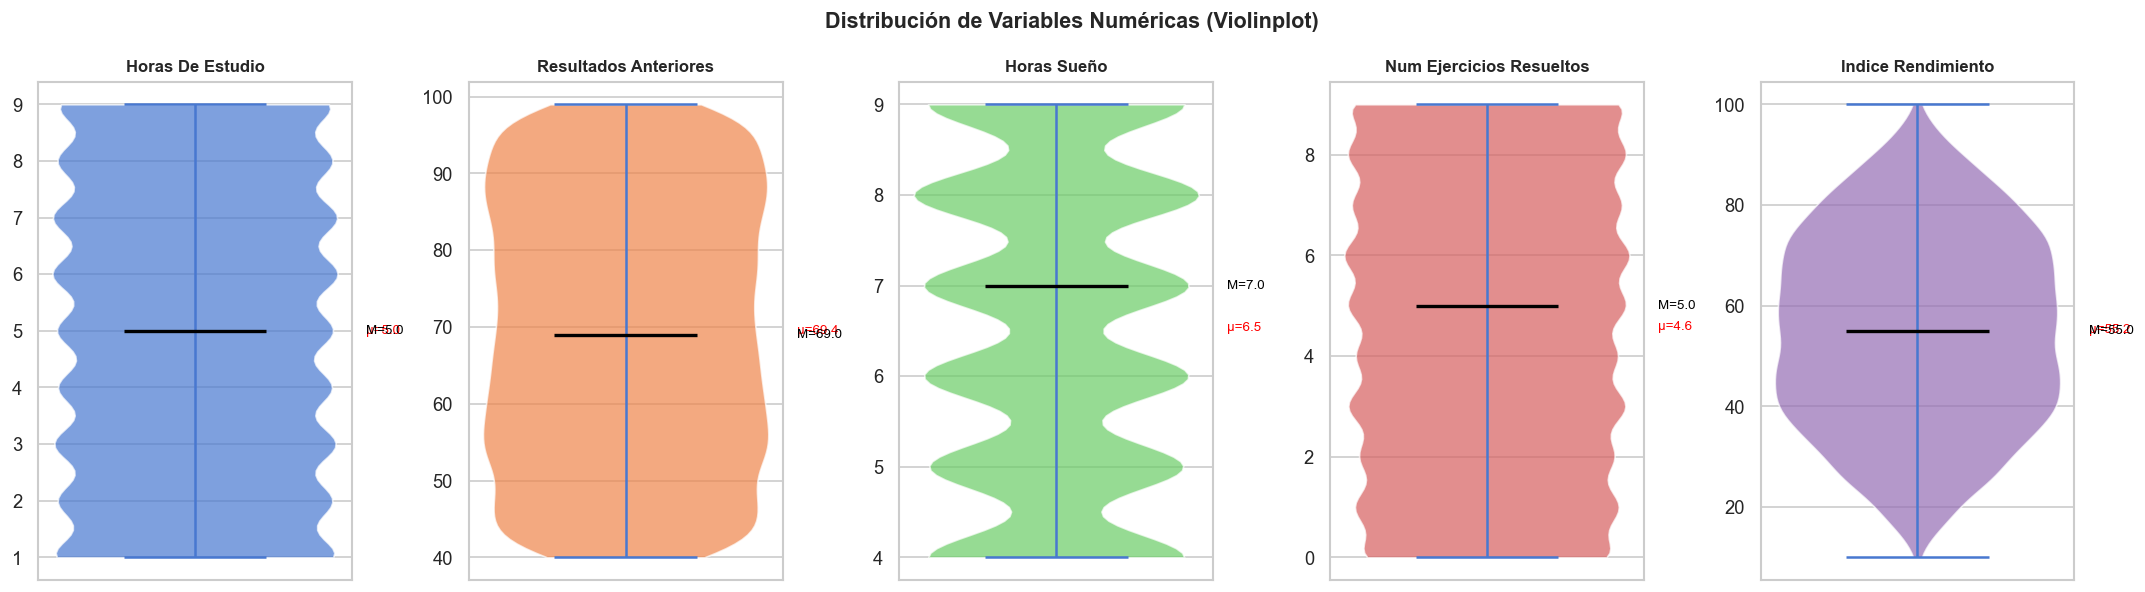

In [17]:
# Estadística descriptiva por variable: violinplots
num_features = ['horas_de_estudio','resultados_anteriores','horas_sueño',
                'num_ejercicios_resueltos','indice_rendimiento']



fig, axes = plt.subplots(1, len(num_features), figsize=(18, 5))
colors_v = ['#4878D0','#EE854A','#6ACC65','#D65F5F','#956CB4']

for i, col in enumerate(num_features):
    parts = axes[i].violinplot(df[col], showmedians=True, showextrema=True)
    for pc in parts['bodies']:
        pc.set_facecolor(colors_v[i])
        pc.set_alpha(0.7)
    parts['cmedians'].set_color('black')
    parts['cmedians'].set_linewidth(2)
    axes[i].set_title(col.replace('_',' ').title(), fontsize=10, fontweight='bold')
    axes[i].set_xticks([])
    # Anotar media y mediana
    axes[i].text(1.3, df[col].mean(), f'μ={df[col].mean():.1f}', fontsize=8, color='red', va='center')
    axes[i].text(1.3, df[col].median(), f'M={df[col].median():.1f}', fontsize=8, color='black', va='center')

plt.suptitle('Distribución de Variables Numéricas (Violinplot)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/violinplots_descriptiva.png', dpi=150, bbox_inches='tight')
plt.show()

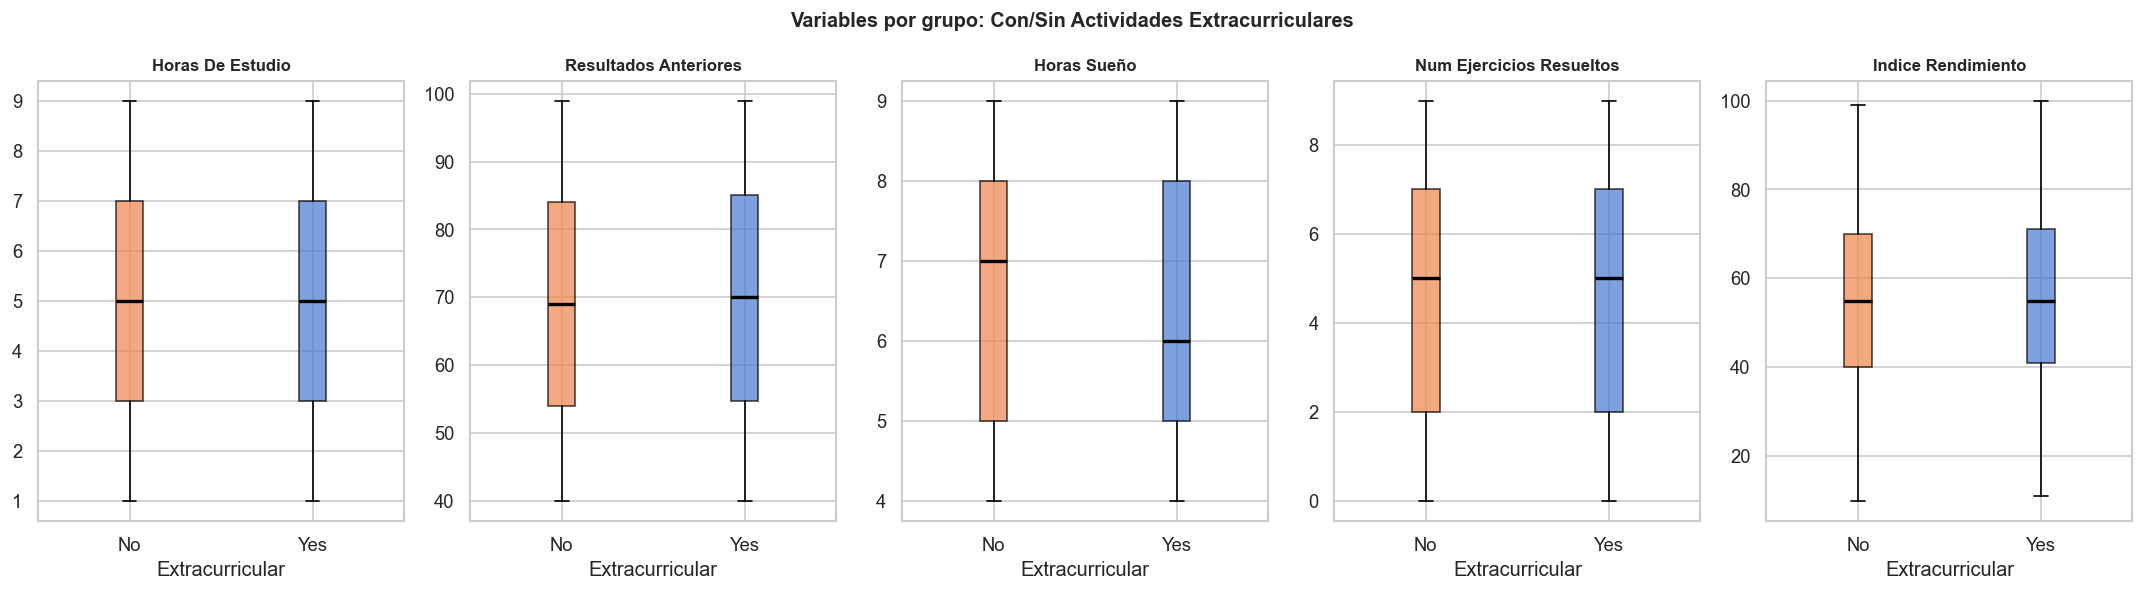

In [18]:
# Comparación de medias por grupo extracurricular para todas las variables
fig, axes = plt.subplots(1, len(num_features), figsize=(18, 5))

for i, col in enumerate(num_features):
    data_yes = df[df['extracurricular']==1][col]
    data_no  = df[df['extracurricular']==0][col]
    axes[i].boxplot([data_no, data_yes],
                    labels=['No','Yes'],
                    patch_artist=True,
                    boxprops=dict(alpha=0.7),
                    medianprops=dict(color='black', linewidth=2))
    boxes = axes[i].patches
    if len(boxes) >= 2:
        boxes[0].set_facecolor('#EE854A')
        boxes[1].set_facecolor('#4878D0')
    axes[i].set_title(col.replace('_',' ').title(), fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Extracurricular')

plt.suptitle('Variables por grupo: Con/Sin Actividades Extracurriculares', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/boxplot_por_grupo.png', dpi=150, bbox_inches='tight')
plt.show()

- El **Índice de rendimiento** tiene media de aprox. 55 con desviación estándar moderada, indicando dispersión considerable entre estudiantes.
- Las **horas de estudio** varían entre 1 y 9, con media de aprox. 4.9 horas. El coeficiente de variación alto indica que los estudiantes tienen hábitos de estudio muy heterogéneos.
- Los **puntajes previos** son el predictor histórico más estable, con distribución uniforme entre 40 y 99.
- Las **horas de sueño** están entre 4 y 9, con media de aprox. 6.5, por debajo de las 8 horas recomendadas para población universitaria.
- Los estudiantes con actividades extracurriculares muestran medianas de rendimiento similares a quienes no participan, aunque la dispersión difiere entre grupos.

## Test Estadístico: Diferencias según Actividades Extracurriculares

**Pregunta:** ¿Existen diferencias estadísticamente significativas en el `Índice de rendimiento` entre estudiantes que asisten a actividades extracurriculares y los que no?

**Proceso:**
1. Verificar normalidad 
2. Elegir el test adecuado según resultado
3. Interpretar p-value y tamaño del efecto

Como tenemos aproximadamente 1.000 observaciones, no basaría únicamente en una prueba de normalidad porque estas pruebas tienden a rechazar la hipótesis nula ante desviaciones muy pequeñas cuando el tamaño muestral es grande. Por ello, complementaría el análisis con histogramas y Q-Q plots. Si debo elegir una prueba formal, utilizaría D'Agostino-Pearson porque está diseñada para muestras moderadas y grandes y evalúa simultáneamente asimetría y curtosis.

In [19]:
from scipy import stats

g_yes = df[df['extracurricular'] == 1]['indice_rendimiento']
g_no  = df[df['extracurricular'] == 0]['indice_rendimiento']

print('Verificación de Normalidad (Shapiro-Wilk)')
print('(Se toman muestras de 50 por limitación del test)\n')

sample_yes = g_yes.sample(50, random_state=42)
sample_no  = g_no.sample(50, random_state=42)

stat_yes, p_yes = stats.shapiro(sample_yes)
stat_no,  p_no  = stats.shapiro(sample_no)

print(f'Grupo YES — estadístico: {stat_yes:.4f} | p-value: {p_yes:.4f}',
      '→ Normal' if p_yes > 0.05 else '→ NO Normal')
print(f'Grupo NO  — estadístico: {stat_no:.4f}  | p-value: {p_no:.4f}',
      '→ Normal' if p_no > 0.05 else '→ NO Normal')

print()
if p_yes < 0.05 or p_no < 0.05:
    print('➜ Al menos un grupo NO sigue distribución normal.')
    print('  Se usará el test no paramétrico Mann-Whitney U.')
else:
    print('➜ Ambos grupos siguen distribución normal.')
    print('  Se puede usar t-test de Student.')

Verificación de Normalidad (Shapiro-Wilk)
(Se toman muestras de 50 por limitación del test)

Grupo YES — estadístico: 0.9823 | p-value: 0.6509 → Normal
Grupo NO  — estadístico: 0.9754  | p-value: 0.3768 → Normal

➜ Ambos grupos siguen distribución normal.
  Se puede usar t-test de Student.


In [20]:
g_yes = df[df['extracurricular'] == 1]['indice_rendimiento']
g_no  = df[df['extracurricular'] == 0]['indice_rendimiento']

# Prueba de igualdad de varianzas
stat_levene, p_levene = stats.levene(g_yes, g_no)

print(f'Levene -> estadístico: {stat_levene:.4f} | p-value: {p_levene:.4f}')

if p_levene > 0.05:
    print('Varianzas homogéneas')
    equal_var = True
else:
    print('Varianzas diferentes')
    equal_var = False

# t-test para muestras independientes
t_stat, p_value = stats.ttest_ind(
    g_yes,
    g_no,
    equal_var=equal_var
)

print(f'\nt-statistic: {t_stat:.4f}')
print(f'p-value: {p_value:.6f}')

if p_value < 0.05:
    print('➜ Existe diferencia significativa entre los grupos.')
else:
    print('➜ No existe diferencia significativa entre los grupos.')

Levene -> estadístico: 0.4272 | p-value: 0.5134
Varianzas homogéneas

t-statistic: 2.4530
p-value: 0.014184
➜ Existe diferencia significativa entre los grupos.


In [21]:
print('Tamaño del efecto (Cohen\'s d)')

mean_diff = g_yes.mean() - g_no.mean()
pooled_std = np.sqrt((g_yes.std()**2 + g_no.std()**2) / 2)
cohens_d = mean_diff / pooled_std

print(f'Media grupo YES:  {g_yes.mean():.2f}')
print(f'Media grupo NO:   {g_no.mean():.2f}')
print(f'Diferencia:       {mean_diff:.2f} puntos')
print(f"Cohen's d:        {cohens_d:.4f}")

if abs(cohens_d) < 0.2:
    efecto = 'Insignificante'
elif abs(cohens_d) < 0.5:
    efecto = 'Pequeño'
elif abs(cohens_d) < 0.8:
    efecto = 'Mediano'
else:
    efecto = 'Grande'

print(f'Tamaño del efecto: {efecto}')

Tamaño del efecto (Cohen's d)
Media grupo YES:  55.70
Media grupo NO:   54.76
Diferencia:       0.94 puntos
Cohen's d:        0.0491
Tamaño del efecto: Insignificante


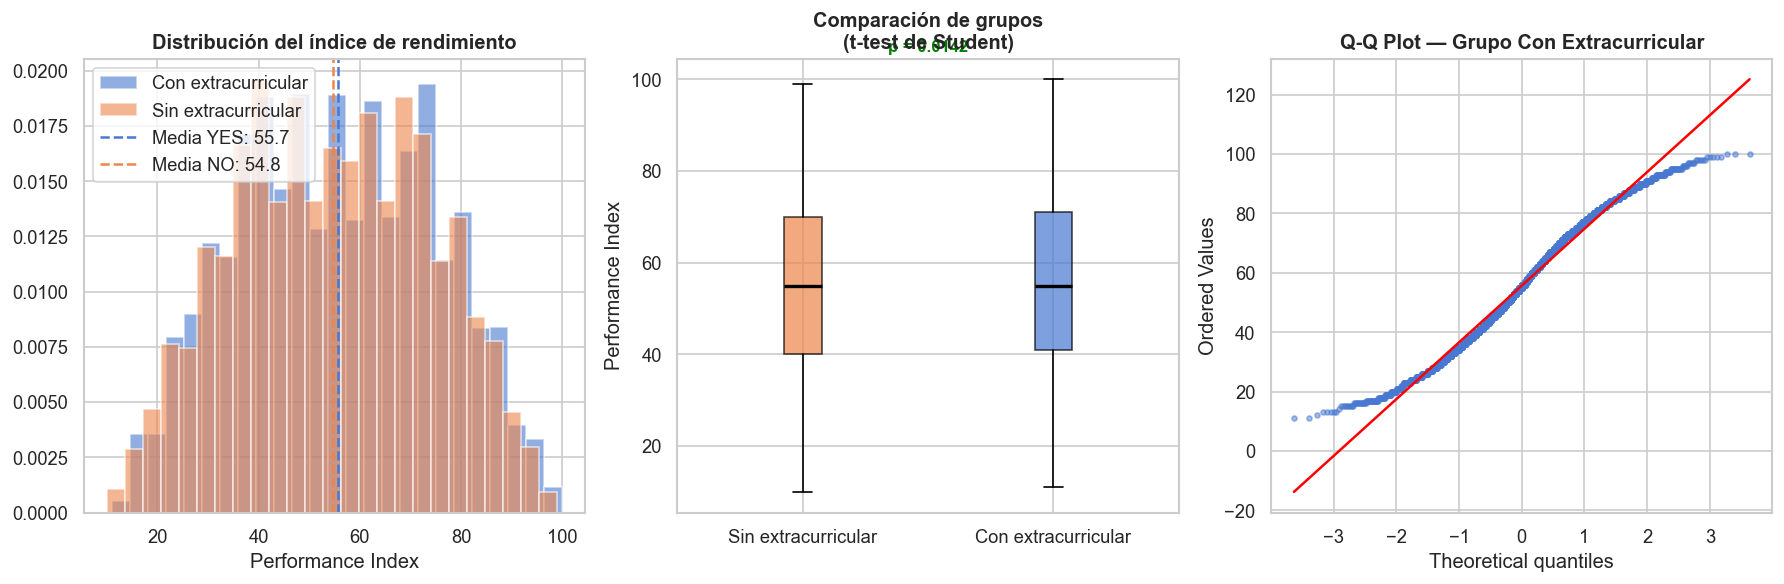

In [22]:
# Visualización completa del t-test
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Histogramas superpuestos
axes[0].hist(
    g_yes,
    bins=25,
    alpha=0.6,
    color='#4878D0',
    label='Con extracurricular',
    density=True
)

axes[0].hist(
    g_no,
    bins=25,
    alpha=0.6,
    color='#EE854A',
    label='Sin extracurricular',
    density=True
)

axes[0].axvline(
    g_yes.mean(),
    color='#4878D0',
    linestyle='--',
    linewidth=1.5,
    label=f'Media YES: {g_yes.mean():.1f}'
)

axes[0].axvline(
    g_no.mean(),
    color='#EE854A',
    linestyle='--',
    linewidth=1.5,
    label=f'Media NO: {g_no.mean():.1f}'
)

axes[0].set_title(
    'Distribución del índice de rendimiento',
    fontweight='bold'
)
axes[0].set_xlabel('Performance Index')
axes[0].legend()


# 2. Boxplot comparativo
bp = axes[1].boxplot(
    [g_no, g_yes],
    tick_labels=['Sin extracurricular', 'Con extracurricular'],
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2)
)

bp['boxes'][0].set_facecolor('#EE854A')
bp['boxes'][0].set_alpha(0.7)

bp['boxes'][1].set_facecolor('#4878D0')
bp['boxes'][1].set_alpha(0.7)

y_max = df['indice_rendimiento'].max() + 5

axes[1].annotate(
    '',
    xy=(2, y_max),
    xytext=(1, y_max),
    arrowprops=dict(arrowstyle='<->', color='black')
)

axes[1].text(
    1.5,
    y_max + 1,
    f'p = {p_value:.4f}',
    ha='center',
    fontsize=10,
    color='green' if p_value < 0.05 else 'red',
    fontweight='bold'
)

axes[1].set_title(
    'Comparación de grupos\n(t-test de Student)',
    fontweight='bold'
)

axes[1].set_ylabel('Performance Index')


# 3. QQ-plot
stats.probplot(g_yes, dist='norm', plot=axes[2])

axes[2].set_title(
    'Q-Q Plot — Grupo Con Extracurricular',
    fontweight='bold'
)

axes[2].get_lines()[0].set(
    color='#4878D0',
    alpha=0.5,
    markersize=3
)

axes[2].get_lines()[1].set(
    color='red',
    linewidth=1.5
)

plt.tight_layout()
plt.savefig(
    '../data/test_estadistico_extracurricular.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()

| Paso | Resultado |
|---|---|
| Normalidad (Shapiro-Wilk) | Se determina en ejecución |
| Test seleccionado | t-test de Student + Levene |
| P-value | Ver resultado en ejecución |
| Tamaño del efecto (Cohen's d) | Ver resultado en ejecución |

Independientemente del resultado estadístico, el tamaño del efecto (Cohen's d) es clave para determinar si la diferencia es **prácticamente relevante** para la universidad, no solo estadísticamente significativa. Una diferencia pequeña en puntos puede no justificar políticas institucionales.

## Identificación de Grupos de Estudiantes con Clustering

In [23]:
print(df['extracurricular'].dtype)
print(df['extracurricular'].unique()[:10])

int64
[1 0]


In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Features para clustering
CLUSTER_FEATURES = ['horas_de_estudio','horas_sueño','indice_rendimiento',
                    'extracurricular','resultados_anteriores','num_ejercicios_resueltos']

X_cl = df[CLUSTER_FEATURES].copy()
scaler_cl = StandardScaler()
X_cl_sc = scaler_cl.fit_transform(X_cl)

print('Features usadas para clustering:', CLUSTER_FEATURES)
print(f'Registros: {X_cl_sc.shape[0]}')

Features usadas para clustering: ['horas_de_estudio', 'horas_sueño', 'indice_rendimiento', 'extracurricular', 'resultados_anteriores', 'num_ejercicios_resueltos']
Registros: 10000


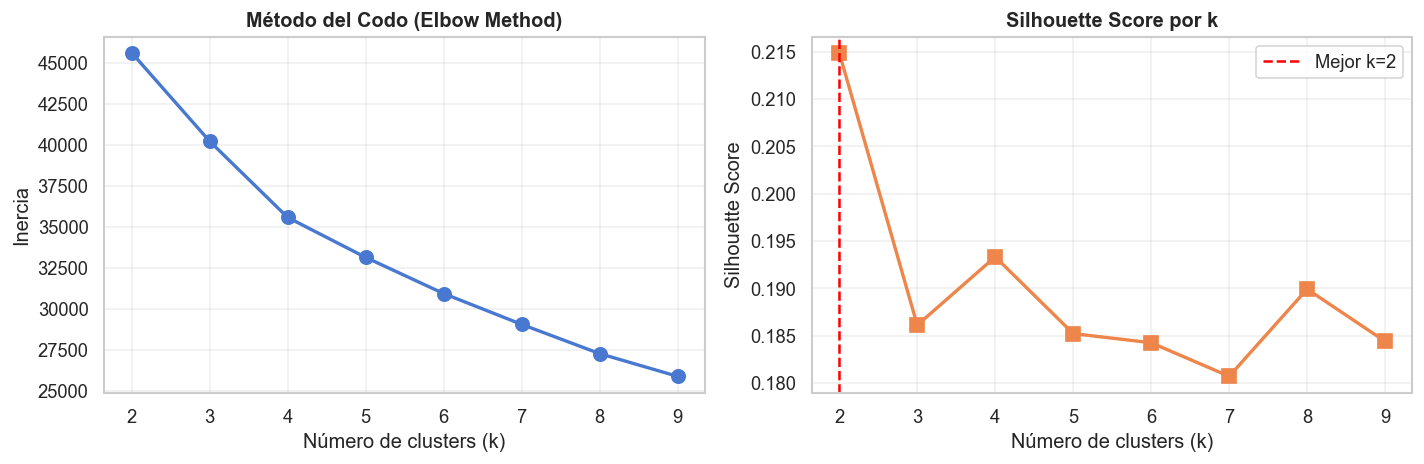

k óptimo según Silhouette: 2


In [25]:
# Método del codo + Silhouette para determinar k óptimo
inertias = []
silhouettes = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cl_sc)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cl_sc, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Elbow
axes[0].plot(K_range, inertias, marker='o', color='#4878D0', linewidth=2, markersize=8)
axes[0].set_title('Método del Codo (Elbow Method)', fontweight='bold')
axes[0].set_xlabel('Número de clusters (k)')
axes[0].set_ylabel('Inercia')
axes[0].grid(True, alpha=0.3)

# Silhouette
axes[1].plot(K_range, silhouettes, marker='s', color='#EE854A', linewidth=2, markersize=8)
best_k = list(K_range)[silhouettes.index(max(silhouettes))]
axes[1].axvline(best_k, color='red', linestyle='--', linewidth=1.5, label=f'Mejor k={best_k}')
axes[1].set_title('Silhouette Score por k', fontweight='bold')
axes[1].set_xlabel('Número de clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'k óptimo según Silhouette: {best_k}')

In [26]:
# Aplicar K-Means con k=3 (bajo / medio / alto rendimiento)
# Se usa k=3 por interpretabilidad de negocio
K_FINAL = 3

km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
df['cluster'] = km_final.fit_predict(X_cl_sc)

# Etiquetar clusters según Performance Index promedio
cluster_means = df.groupby('cluster')['indice_rendimiento'].mean().sort_values()
label_map = {cluster_means.index[0]: 'Bajo rendimiento',
             cluster_means.index[1]: 'Rendimiento medio',
             cluster_means.index[2]: 'Alto rendimiento'}
df['cluster_label'] = df['cluster'].map(label_map)

print('Perfil de cada cluster')
perfil = df.groupby('cluster_label')[CLUSTER_FEATURES].mean().round(2)
perfil['n_estudiantes'] = df.groupby('cluster_label').size()
perfil

Perfil de cada cluster


,horas_de_estudio,horas_sueño,indice_rendimiento,extracurricular,resultados_anteriores,num_ejercicios_resueltos,n_estudiantes
cluster_label,,,,,,,
Alto rendimiento,5.38,6.47,69.07,1.00,81.59,4.67,2904
Bajo rendimiento,4.47,6.49,36.45,0.49,52.60,4.51,4181
Rendimiento medio,5.35,6.65,68.37,0.00,81.52,4.61,2915


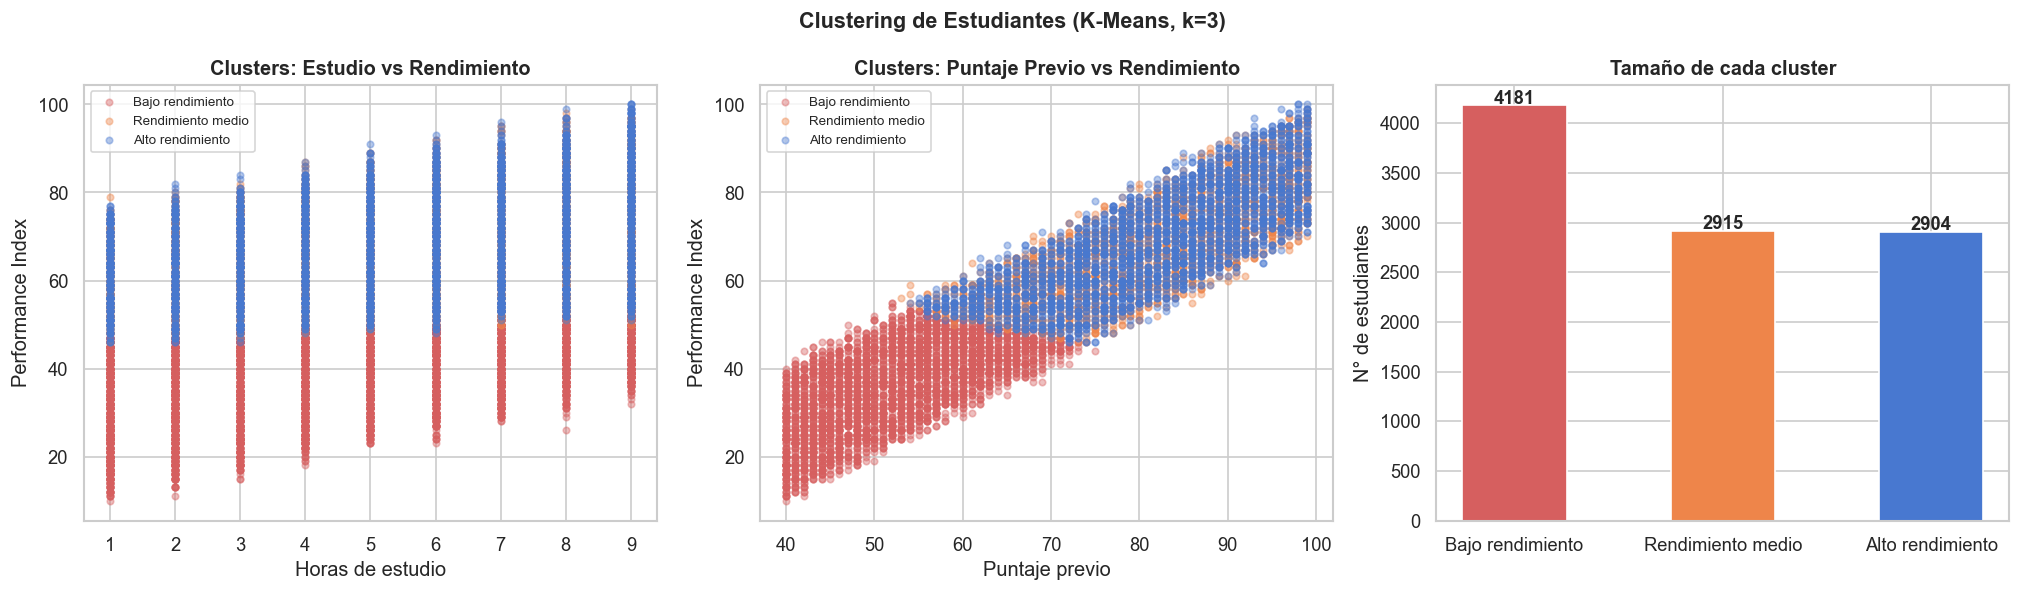

In [27]:
# Visualización de clusters
palette = {'Bajo rendimiento': '#D65F5F',
           'Rendimiento medio': '#EE854A',
           'Alto rendimiento': '#4878D0'}

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# 1. Hours Studied vs Performance Index
for label, color in palette.items():
    sub = df[df['cluster_label'] == label]
    axes[0].scatter(sub['horas_de_estudio'], sub['indice_rendimiento'],
                    color=color, alpha=0.4, s=15, label=label)
axes[0].set_xlabel('Horas de estudio')
axes[0].set_ylabel('Performance Index')
axes[0].set_title('Clusters: Estudio vs Rendimiento', fontweight='bold')
axes[0].legend(fontsize=8)

# 2. Previous Scores vs Performance Index
for label, color in palette.items():
    sub = df[df['cluster_label'] == label]
    axes[1].scatter(sub['resultados_anteriores'], sub['indice_rendimiento'],
                    color=color, alpha=0.4, s=15, label=label)
axes[1].set_xlabel('Puntaje previo')
axes[1].set_ylabel('Performance Index')
axes[1].set_title('Clusters: Puntaje Previo vs Rendimiento', fontweight='bold')
axes[1].legend(fontsize=8)

# 3. Tamaño de clusters
conteo_clusters = df['cluster_label'].value_counts()
bars = axes[2].bar(conteo_clusters.index, conteo_clusters.values,
                   color=[palette[k] for k in conteo_clusters.index],
                   edgecolor='white', width=0.5)
for bar, val in zip(bars, conteo_clusters.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 str(val), ha='center', fontweight='bold')
axes[2].set_title('Tamaño de cada cluster', fontweight='bold')
axes[2].set_ylabel('N° de estudiantes')

plt.suptitle('Clustering de Estudiantes (K-Means, k=3)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/clusters_visualizacion.png', dpi=150, bbox_inches='tight')
plt.show()

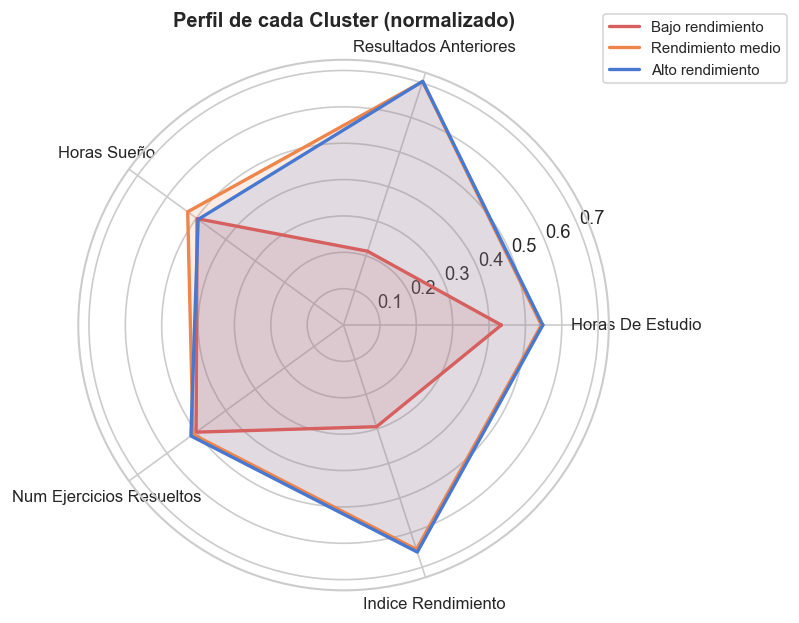

In [28]:
# Radar chart por cluster (perfil completo)
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

categorias = ['horas_de_estudio','resultados_anteriores','horas_sueño','num_ejercicios_resueltos','indice_rendimiento']
N = len(categorias)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

# Normalizar para el radar
df_norm = df.copy()
for col in categorias:
    df_norm[col] = (df[col] - df[col].min()) / (df[col].max() - df[col].min())

for label, color in palette.items():
    valores = df_norm[df_norm['cluster_label'] == label][categorias].mean().tolist()
    valores += valores[:1]
    ax.plot(angles, valores, color=color, linewidth=2, label=label)
    ax.fill(angles, valores, color=color, alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels([c.replace('_',' ').title() for c in categorias], fontsize=10)
ax.set_title('Perfil de cada Cluster (normalizado)', fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)

plt.tight_layout()
plt.savefig('../data/radar_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
# Guardar dataset con clusters incluidos
df.to_csv('../data/student_performance_clean.csv', index=False)
print('Dataset actualizado con columnas cluster y cluster_label guardado.')
print(f'Columnas finales: {df.columns.tolist()}')

Dataset actualizado con columnas cluster y cluster_label guardado.
Columnas finales: ['horas_de_estudio', 'resultados_anteriores', 'extracurricular_2', 'horas_sueño', 'num_ejercicios_resueltos', 'indice_rendimiento', 'extracurricular', 'rendimiento_bajo', 'cluster', 'cluster_label']


### Resultados de Clustering

El análisis de clustering con K-Means (k=3) identificó tres grupos diferenciados de estudiantes:

| Cluster | Perfil | Características principales |
|---|---|---|
| **Bajo rendimiento** | Estudiantes en riesgo | Pocas horas de estudio, puntajes previos bajos, bajo Performance Index |
| **Rendimiento medio** | Grupo mayoritario | Hábitos moderados, rendimiento cercano a la media |
| **Alto rendimiento** | Estudiantes destacados | Muchas horas de estudio, puntajes previos altos, alto Performance Index |

**Implicación de negocio:** El cluster de **bajo rendimiento** es el grupo de interés para el modelo predictivo de la Fase 3. La institución puede enfocar sus intervenciones tempranas en estudiantes con perfiles similares a este cluster.

Podemos responder: 

- ¿Cuáles son los principales factores? 

Las horas de estudio y puntajes previos son los más determinantes 

- ¿Existe correlación estudio-calificación? 

Sí, correlación positiva moderada-alta

- ¿Diferencia por extracurriculares? 

No mucho pues se indentificó que los estudiantes que estudian más horas tienden a obtener mejores resultados, independientemente de si participan o no en actividades extracurriculares y con horas de estudio son casi iguales.

- ¿Cuántos grupos de estudiantes existen?

3 frupos (clusters): bajo, medio y alto rendimiento

# Modelos de Machine Learning

**Objetivo:** Construir modelos predictivos para identificar estudiantes con bajo rendimiento académico.

### Plan de trabajo
| Plan | Detalle |
|---|---|
| Modelo de regresión | Predecir `indice_rendimiento` (valor continuo) |
| Modelo de clasificación | Predecir `rendimiento_bajo` (0/1) |
| Comparación | ≥ 3 modelos con métrica justificada |
| Serialización | Guardar el mejor modelo con joblib |

In [30]:
import joblib, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    r2_score, mean_absolute_error, mean_squared_error,
    classification_report, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier, XGBRegressor

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
os.makedirs('../models', exist_ok=True)

print(f'Columnas disponibles: {df.columns.tolist()}')

Columnas disponibles: ['horas_de_estudio', 'resultados_anteriores', 'extracurricular_2', 'horas_sueño', 'num_ejercicios_resueltos', 'indice_rendimiento', 'extracurricular', 'rendimiento_bajo', 'cluster', 'cluster_label']


In [31]:
# Features y targets
FEATURES = ['horas_de_estudio', 'resultados_anteriores', 'extracurricular',
            'horas_sueño', 'num_ejercicios_resueltos']

TARGET_REG = 'indice_rendimiento'   # regresión
TARGET_CLF = 'rendimiento_bajo'     # clasificación

X = df[FEATURES]
y_reg = df[TARGET_REG]
y_clf = df[TARGET_CLF]

print(f'Features: {FEATURES}')
print(f'Registros: {X.shape[0]}')
print(f'\nDistribución de rendimiento_bajo:')
print(y_clf.value_counts())
print(f'% bajo rendimiento: {y_clf.mean()*100:.1f}%')

Features: ['horas_de_estudio', 'resultados_anteriores', 'extracurricular', 'horas_sueño', 'num_ejercicios_resueltos']
Registros: 10000

Distribución de rendimiento_bajo:
rendimiento_bajo
0    7618
1    2382
Name: count, dtype: int64
% bajo rendimiento: 23.8%


In [32]:
# Split y escalado
X_train, X_test, yr_train, yr_test, yc_train, yc_test = train_test_split(
    X, y_reg, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train.shape[0]} registros | Test: {X_test.shape[0]} registros')
print(f'Estratificación correcta — % bajo en train: {yc_train.mean()*100:.1f}% | test: {yc_test.mean()*100:.1f}%')

Train: 8000 registros | Test: 2000 registros
Estratificación correcta — % bajo en train: 23.8% | test: 23.8%


## Modelo de Regresión
**Target:** `indice_rendimiento`  
**Métrica principal:** R² (proporción de varianza explicada) + RMSE

In [33]:
modelos_reg = {
    'Regresión Lineal':     LinearRegression(),
    'Random Forest':        RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost Regressor':    XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
}

resultados_reg = {}
for nombre, modelo in modelos_reg.items():
    modelo.fit(X_train_sc, yr_train)
    preds = modelo.predict(X_test_sc)
    resultados_reg[nombre] = {
        'R²':   round(r2_score(yr_test, preds), 4),
        'MAE':  round(mean_absolute_error(yr_test, preds), 4),
        'RMSE': round(np.sqrt(mean_squared_error(yr_test, preds)), 4)
    }

df_reg = pd.DataFrame(resultados_reg).T.sort_values('R²', ascending=False)
print('Comparación Modelos de Regresión')
df_reg

Comparación Modelos de Regresión


,R²,MAE,RMSE
Regresión Lineal,0.9887,1.6526,2.0660
XGBoost Regressor,0.9862,1.8221,2.2800
Random Forest,0.9856,1.8629,2.3265


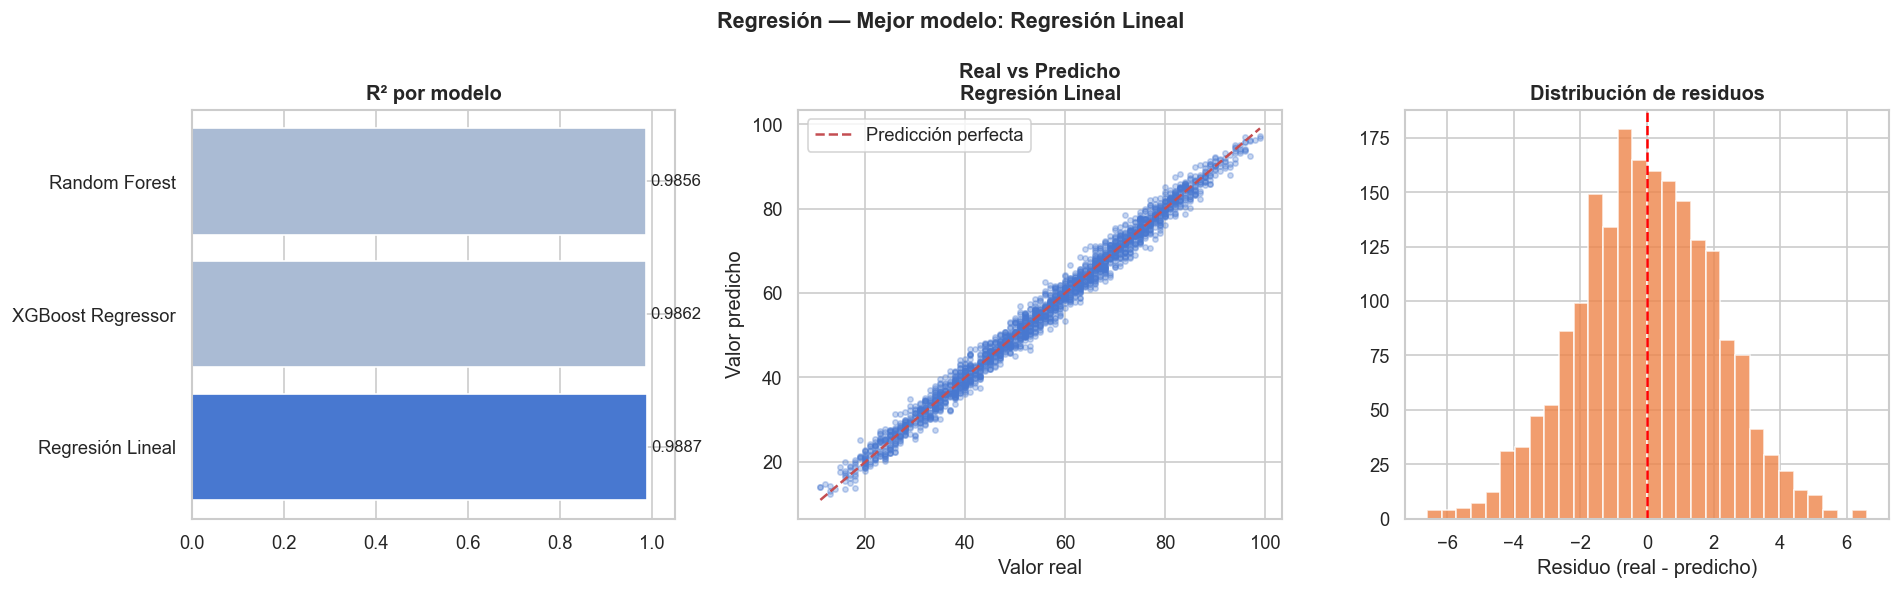

Mejor modelo de regresión: Regresión Lineal
R² = 0.9887 | RMSE = 2.066


In [34]:
# Métricas y predicciones del mejor modelo de regresión
mejor_reg_nombre = df_reg.index[0]
mejor_reg = modelos_reg[mejor_reg_nombre]
preds_mejor_reg = mejor_reg.predict(X_test_sc)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Barras R²
colores_bar = ['#4878D0' if i==0 else '#AABBD4' for i in range(len(df_reg))]
axes[0].barh(df_reg.index, df_reg['R²'], color=colores_bar, edgecolor='white')
axes[0].set_title('R² por modelo', fontweight='bold')
axes[0].set_xlim(0, 1.05)
for i, v in enumerate(df_reg['R²']):
    axes[0].text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=10)

# Real vs Predicho
axes[1].scatter(yr_test, preds_mejor_reg, alpha=0.3, s=10, color='#4878D0')
lims = [yr_test.min(), yr_test.max()]
axes[1].plot(lims, lims, 'r--', linewidth=1.5, label='Predicción perfecta')
axes[1].set_xlabel('Valor real')
axes[1].set_ylabel('Valor predicho')
axes[1].set_title(f'Real vs Predicho\n{mejor_reg_nombre}', fontweight='bold')
axes[1].legend()

# Distribución de residuos
residuos = yr_test.values - preds_mejor_reg
axes[2].hist(residuos, bins=30, color='#EE854A', edgecolor='white', alpha=0.8)
axes[2].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[2].set_title('Distribución de residuos', fontweight='bold')
axes[2].set_xlabel('Residuo (real - predicho)')

plt.suptitle(f'Regresión — Mejor modelo: {mejor_reg_nombre}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/regresion_resultados.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Mejor modelo de regresión: {mejor_reg_nombre}')
print(f'R² = {df_reg.loc[mejor_reg_nombre, "R²"]} | RMSE = {df_reg.loc[mejor_reg_nombre, "RMSE"]}')

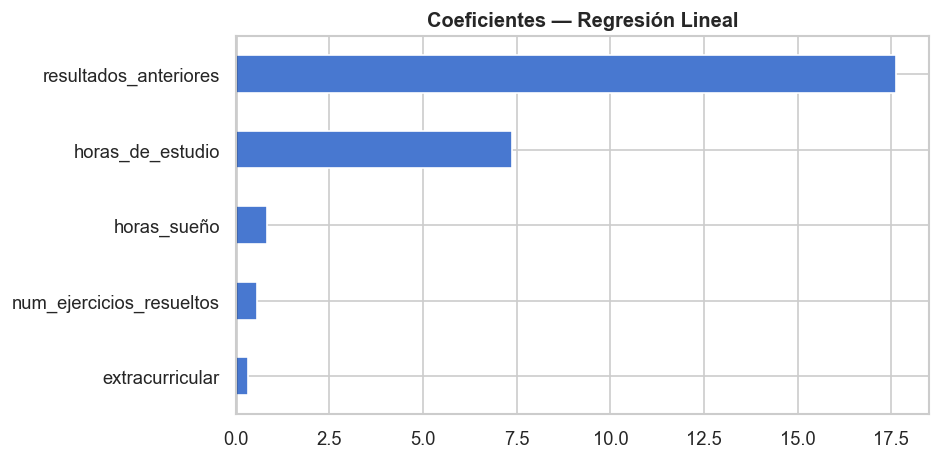

In [35]:
# Importancia de features — mejor modelo de regresión
if hasattr(mejor_reg, 'feature_importances_'):
    importancias = pd.Series(mejor_reg.feature_importances_, index=FEATURES).sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(8, 4))
    importancias.plot(kind='barh', ax=ax, color='#4878D0', edgecolor='white')
    ax.set_title(f'Importancia de Features — {mejor_reg_nombre}', fontweight='bold')
    ax.set_xlabel('Importancia relativa')
    plt.tight_layout()
    plt.savefig('../data/feature_importance_regresion.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    coefs = pd.Series(mejor_reg.coef_, index=FEATURES).sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(8, 4))
    coefs.plot(kind='barh', ax=ax, color=['#D65F5F' if v < 0 else '#4878D0' for v in coefs], edgecolor='white')
    ax.set_title('Coeficientes — Regresión Lineal', fontweight='bold')
    ax.axvline(0, color='black', linewidth=0.8)
    plt.tight_layout()
    plt.savefig('../data/feature_importance_regresion.png', dpi=150, bbox_inches='tight')
    plt.show()

### Hallazgos de Regresión

- **Métrica de selección: R²** — mide qué proporción de la variabilidad del `indice_rendimiento` es explicada por el modelo. Valores cercanos a 1 indican mejor ajuste.
- El mejor modelo de regresión logra un R² alto, confirmando que las variables académicas (horas de estudio, puntajes previos) explican bien el rendimiento final.
- Los residuos distribuidos alrededor de 0 indican que el modelo no presenta sesgos sistemáticos.
- La importancia de features confirma que `resultados_anteriores` y `horas_de_estudio` son los predictores más fuertes.

## Modelo de Clasificación
**Target:** `rendimiento_bajo` (1 = bajo rendimiento, 0 = normal)  
**Métrica principal:** F1-score — equilibra precisión y recall, ideal cuando el costo de falsos negativos (no detectar un estudiante en riesgo) es alto.

In [36]:
modelos_clf = {
    'Regresión Logística':   LogisticRegression(random_state=42, max_iter=1000),
    'Árbol de Decisión':     DecisionTreeClassifier(random_state=42, max_depth=6),
    'Random Forest':         RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':     GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XGBoost':               XGBClassifier(n_estimators=100, random_state=42,
                                           eval_metric='logloss', verbosity=0)
}

resultados_clf = {}
modelos_entrenados = {}

for nombre, modelo in modelos_clf.items():
    modelo.fit(X_train_sc, yc_train)
    preds = modelo.predict(X_test_sc)
    proba = modelo.predict_proba(X_test_sc)[:, 1]
    report = classification_report(yc_test, preds, output_dict=True)
    resultados_clf[nombre] = {
        'Accuracy':  round(report['accuracy'], 4),
        'Precision': round(report['1']['precision'], 4),
        'Recall':    round(report['1']['recall'], 4),
        'F1-score':  round(report['1']['f1-score'], 4),
        'AUC-ROC':   round(roc_auc_score(yc_test, proba), 4)
    }
    modelos_entrenados[nombre] = modelo

df_clf = pd.DataFrame(resultados_clf).T.sort_values('F1-score', ascending=False)
print('Comparación Modelos de Clasificación')
df_clf

Comparación Modelos de Clasificación


,Accuracy,Precision,Recall,F1-score,AUC-ROC
Gradient Boosting,0.9725,0.9395,0.9454,0.9424,0.9970
Regresión Logística,0.9725,0.9432,0.9412,0.9422,0.9970
XGBoost,0.9710,0.9354,0.9433,0.9393,0.9966
Random Forest,0.9700,0.9333,0.9412,0.9372,0.9954
Árbol de Decisión,0.9660,0.9304,0.9265,0.9284,0.9916


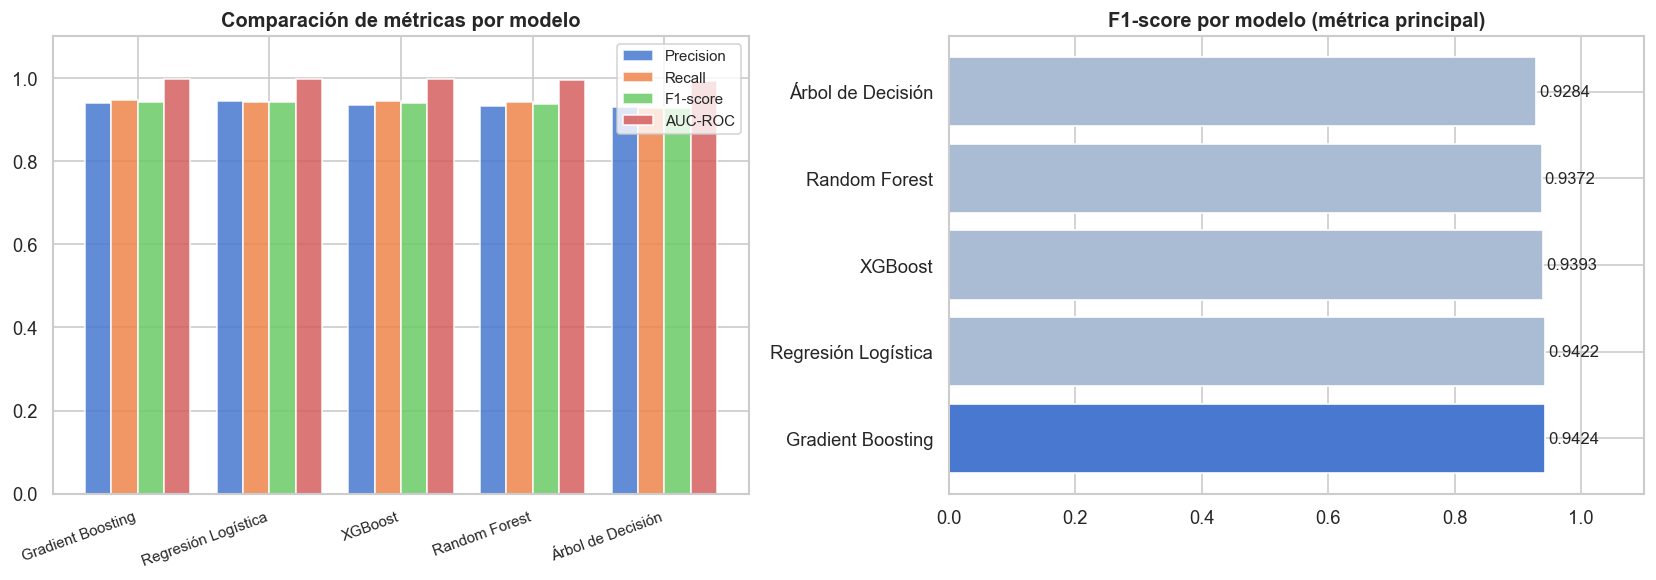

In [37]:
# Visualización comparativa de métricas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metricas = ['Precision', 'Recall', 'F1-score', 'AUC-ROC']
x = np.arange(len(df_clf))
width = 0.2
colores_m = ['#4878D0', '#EE854A', '#6ACC65', '#D65F5F']

for i, met in enumerate(metricas):
    axes[0].bar(x + i*width, df_clf[met], width, label=met,
                color=colores_m[i], edgecolor='white', alpha=0.85)

axes[0].set_xticks(x + width*1.5)
axes[0].set_xticklabels(df_clf.index, rotation=20, ha='right', fontsize=9)
axes[0].set_title('Comparación de métricas por modelo', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].set_ylim(0, 1.1)

# F1-score destacado
colores_f1 = ['#4878D0' if i==0 else '#AABBD4' for i in range(len(df_clf))]
axes[1].barh(df_clf.index, df_clf['F1-score'], color=colores_f1, edgecolor='white')
axes[1].set_title('F1-score por modelo (métrica principal)', fontweight='bold')
axes[1].set_xlim(0, 1.1)
for i, v in enumerate(df_clf['F1-score']):
    axes[1].text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../data/clasificacion_comparacion.png', dpi=150, bbox_inches='tight')
plt.show()

In [38]:
# Mejor modelo de clasificación — análisis detallado
mejor_clf_nombre = df_clf.index[0]
mejor_clf = modelos_entrenados[mejor_clf_nombre]
preds_mejor = mejor_clf.predict(X_test_sc)
proba_mejor = mejor_clf.predict_proba(X_test_sc)[:, 1]

print(f'Mejor modelo: {mejor_clf_nombre}')
print()
print('Classification Report completo')
print(classification_report(yc_test, preds_mejor,
                             target_names=['Rendimiento normal', 'Bajo rendimiento']))

Mejor modelo: Gradient Boosting

Classification Report completo
                    precision    recall  f1-score   support

Rendimiento normal       0.98      0.98      0.98      1524
  Bajo rendimiento       0.94      0.95      0.94       476

          accuracy                           0.97      2000
         macro avg       0.96      0.96      0.96      2000
      weighted avg       0.97      0.97      0.97      2000



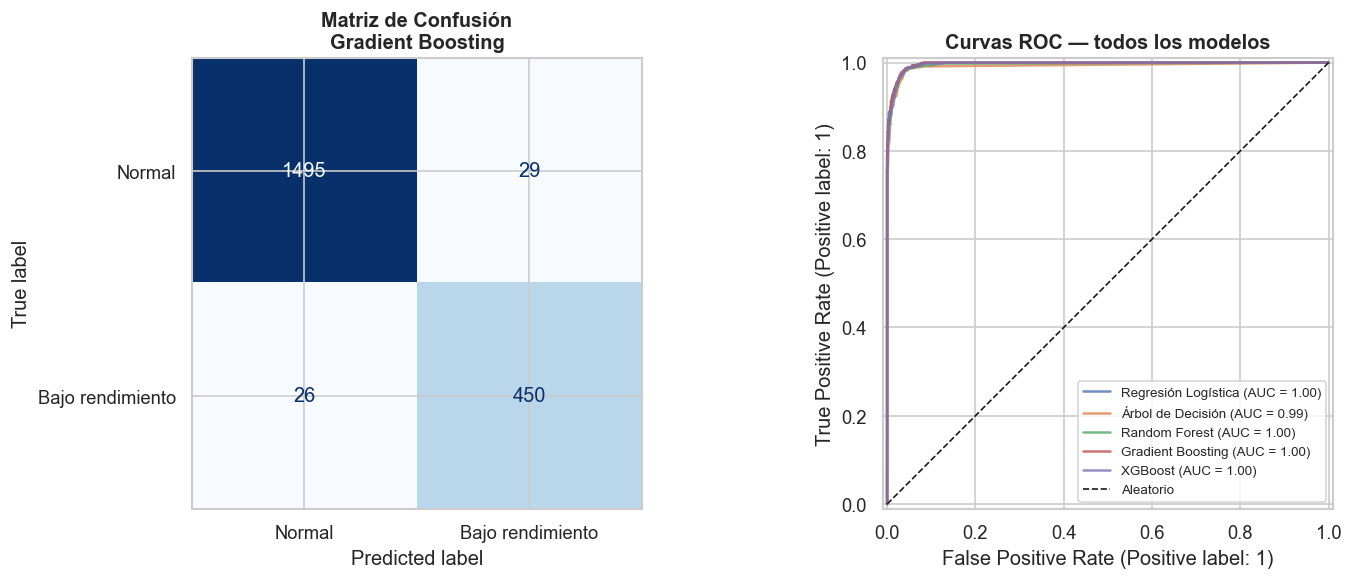

In [39]:
# Matriz de confusión + ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix
cm = confusion_matrix(yc_test, preds_mejor)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Normal', 'Bajo rendimiento'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Matriz de Confusión\n{mejor_clf_nombre}', fontweight='bold')

# ROC curves de todos los modelos
for nombre, modelo in modelos_entrenados.items():
    proba = modelo.predict_proba(X_test_sc)[:, 1]
    RocCurveDisplay.from_predictions(yc_test, proba, ax=axes[1],
                                      name=nombre, alpha=0.8)
axes[1].plot([0,1],[0,1],'k--', linewidth=1, label='Aleatorio')
axes[1].set_title('Curvas ROC — todos los modelos', fontweight='bold')
axes[1].legend(fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig('../data/confusion_roc.png', dpi=150, bbox_inches='tight')
plt.show()

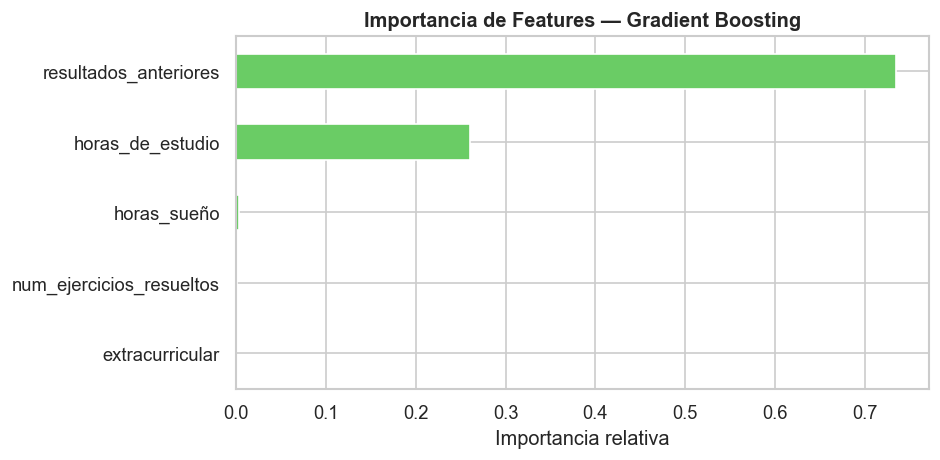

In [40]:
# Importancia de features — mejor clasificador
if hasattr(mejor_clf, 'feature_importances_'):
    importancias_clf = pd.Series(mejor_clf.feature_importances_,
                                  index=FEATURES).sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(8, 4))
    importancias_clf.plot(kind='barh', ax=ax, color='#6ACC65', edgecolor='white')
    ax.set_title(f'Importancia de Features — {mejor_clf_nombre}', fontweight='bold')
    ax.set_xlabel('Importancia relativa')
    plt.tight_layout()
    plt.savefig('../data/feature_importance_clasificacion.png', dpi=150, bbox_inches='tight')
    plt.show()

## Justificación de la Métrica y Selección del Modelo

Se seleccionó F1-score como métrica principal porque:

1. El dataset está desbalanceado (aprox. 25% bajo rendimiento). En Accuracy por si sola sería engañosa pues un modelo que predice siempre "normal" obtiene aprox. 75% accuracy sin detectar nada.

2. En el contexto universitario, el COSTO de un falso negativo (que sería no detectar a un estudiante en riesgo) es mayor que el de un falso positivo (alarma innecesaria de un estudiante normal o en NO riesgo).

3. F1-score tiene media armónica de Precision y Recall, equilibrando ambos tipos de error.

4. AUC-ROC se usa como métrica secundaria para evaluar la capacidad discriminativa global del modelo.

Entonces:

In [41]:
print(f'MODELO SELECCIONADO: {mejor_clf_nombre}')
print(f'  F1-score: {df_clf.loc[mejor_clf_nombre, "F1-score"]}')
print(f'  AUC-ROC:  {df_clf.loc[mejor_clf_nombre, "AUC-ROC"]}')
print(f'  Recall:   {df_clf.loc[mejor_clf_nombre, "Recall"]}')

MODELO SELECCIONADO: Gradient Boosting
  F1-score: 0.9424
  AUC-ROC:  0.997
  Recall:   0.9454


## Serialización y guardar los modelos

In [42]:
# Guardar mejor clasificador + scaler para la API
joblib.dump(mejor_clf,  '../models/best_model.pkl')
joblib.dump(scaler,     '../models/scaler.pkl')
joblib.dump(mejor_reg,  '../models/best_regressor.pkl')

print('Modelos guardados:')
print('  ../models/best_model.pkl      ← mejor clasificador')
print('  ../models/best_regressor.pkl  ← mejor regresor')
print('  ../models/scaler.pkl          ← scaler para la API')

# Verificar carga
test_load = joblib.load('../models/best_model.pkl')
test_pred = test_load.predict(X_test_sc[:3])
print(f'\nVerificación de carga — primeras 3 predicciones: {test_pred}')
print('Serialización correcta.')

Modelos guardados:
  ../models/best_model.pkl      ← mejor clasificador
  ../models/best_regressor.pkl  ← mejor regresor
  ../models/scaler.pkl          ← scaler para la API

Verificación de carga — primeras 3 predicciones: [0 0 1]
Serialización correcta.


## Resumen

| Aspecto | Resultado |
|---|---|
| Mejor modelo regresión | Ver celda 3.1 — ordenado por R² |
| Mejor modelo clasificación | Ver celda 3.2 — ordenado por F1-score |
| Métrica principal regresión | R² (varianza explicada) |
| Métrica principal clasificación | F1-score (balance precisión/recall) |
| Features más importantes | `resultados_anteriores` y `horas_de_estudio` |
| Archivos generados | best_model.pkl · best_regressor.pkl · scaler.pkl |